# Object Detection and Tracking on Video

This notebook implements a computer vision pipeline for detecting and tracking multiple object classes in a custom-recorded video. The pipeline leverages a pre-trained **Mask R-CNN** model (ResNet-50 FPN backbone, trained on MS COCO) to generate per-frame bounding box detections, applies class-specific confidence thresholding to filter noisy predictions, and implements an **IoU-based multi-class object tracker** to assign persistent IDs across frames.

The workflow is structured across three tasks:
- **Task 1** — Video ingestion and Mask R-CNN inference
- **Task 2** — Detection filtering and visualisation
- **Task 3** — Object tracking and annotated output video generation

In [2]:
RANDOM_STATE = 12345

## Environment Setup

**Enabling GPU Acceleration:**  
Mask R-CNN inference is computationally intensive. To significantly reduce processing time, enable GPU acceleration before running any inference cells.  
Go to: **Runtime → Change runtime type → Hardware accelerator → GPU**

## 1. Imports and Dependencies

The following standard and third-party libraries are imported:
- **`torch` / `torchvision`** — Deep learning framework and pre-trained model weights
- **`cv2` (OpenCV)** — Video I/O and image annotation
- **`numpy`** — Numerical array operations
- **`matplotlib`** — In-notebook visualisation
- **`scipy`** — Utility functions (available for assignment tasks)
- **`google.colab.drive`** — Mounts Google Drive to enable persistent file access

In [1]:
import copy
import math
import random

import numpy as np
import cv2
import matplotlib.pyplot as plt
import scipy
import scipy.optimize
import torch
import torchvision
import torchvision.transforms.functional as tvtf

from google.colab import drive

## 2. Google Drive Integration

Connecting this notebook to Google Drive allows us to:
1. Read the input video file (`task1.mp4`) from a persistent location
2. Save generated detection files so they do not need to be recomputed across sessions
3. Write the output annotated video files for submission

**Setup steps:**
1. Navigate to [Google Drive](https://drive.google.com/) and create a top-level folder named `CSE3VIS_Assignment`
2. Upload your recorded video (e.g. `task1.mp4`) into that folder
3. Run the cell below — follow the OAuth prompts to grant access

In [10]:
drive.mount('/content/drive')
%cd /content/drive/MyDrive/CSE3VIS_Assignment

Mounted at /content/drive
/content/drive/MyDrive/CSE3VIS_Assignment


## 3. Video Preview

Before running inference, we verify that the video file is accessible and readable by OpenCV's `VideoCapture` interface. The first frame is decoded, converted from BGR to RGB colour space, and rendered inline.

This sanity check confirms the correct file path is set and that the video codec is supported.

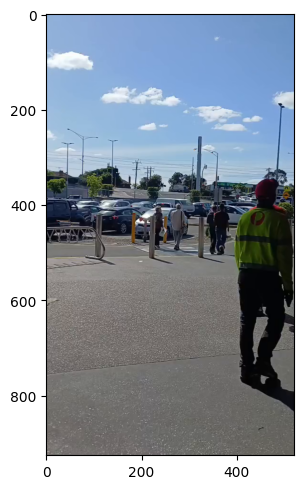

In [11]:
filename = './task1.mp4'

vid = cv2.VideoCapture(filename)
_, img = vid.read()

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig = plt.figure(figsize=(10, 5))
ax = plt.subplot(1, 1, 1)
ax.imshow(img)
fig.tight_layout()

## 4. Mask R-CNN Inference

We load the pre-trained **Mask R-CNN ResNet-50 FPN** model from `torchvision`. This model was trained on the MS COCO dataset and is capable of detecting instances from 80 object categories.

The model is evaluated in inference mode (`model.eval()`). If a CUDA-capable GPU is detected, the model and input tensors are moved to the GPU for accelerated inference.

For each frame in the video, we:
1. Decode the frame and convert it to RGB
2. Transform it to a normalised PyTorch tensor
3. Run a forward pass through the network (with gradients disabled via `torch.no_grad()`)
4. Extract the predicted bounding boxes, class labels, and confidence scores

All detections are stored in-memory and persisted to Google Drive as `.pt` files. **This cell only needs to be run once per video** — subsequent sessions can reload the saved detections directly.

In [12]:
def preprocess_image(image):
    image = tvtf.to_tensor(image)
    image = image.unsqueeze(dim=0)
    return image

maskrcnn = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
maskrcnn.eval()
if torch.cuda.is_available():
    maskrcnn.cuda()

# Go to the start of the video
vid.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Record how long the video is (in frames)
vid_length = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))

# For each frame, read it, give it to maskrcnn and record the detections
all_boxes = []
all_labels = []
all_scores = []
for i in range(vid_length):
    _, img = vid.read()
    if img is None:
        break
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with torch.no_grad():
        input_image = preprocess_image(img)
        if torch.cuda.is_available():
            input_image = input_image.cuda()
        result = maskrcnn(input_image)[0]

    all_boxes.append(result['boxes'].detach().cpu().numpy())
    all_labels.append(result['labels'].detach().cpu().numpy())
    all_scores.append(result['scores'].detach().cpu().numpy())
    if i % 50 == 0:
        print(f'{i+1:0d}/{vid_length}')

torch.save(all_boxes, 'all_boxes.pt')
torch.save(all_labels, 'all_labels.pt')
torch.save(all_scores, 'all_scores.pt')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 449MB/s]


1/719
51/719
101/719
151/719
201/719
251/719
301/719
351/719
401/719
451/719
501/719
551/719
601/719
651/719
701/719


Now if you go to the `CSE3VIS_Assignment` folder on Google Drive you should see three new files where the detections have been stored: `all_boxes.pt`, `all_labels.pt`, and `all_scores.pt`.

Let's load these detections from Google Drive now:

In [13]:
all_boxes = torch.load('all_boxes.pt', weights_only=False)
all_labels = torch.load('all_labels.pt', weights_only=False)
all_scores = torch.load('all_scores.pt', weights_only=False)

vid_length = len(all_boxes)

print(f'Loaded detections for {vid_length} video frames')

Loaded detections for 719 video frames


---
# Task 1 - COCO Class Definitions and Target Class Selection

## 6. MS COCO Class Index Mapping

The Mask R-CNN model outputs integer class labels in the range `[0, 80]`, where index `0` corresponds to the background class. The list below maps each integer index to its corresponding MS COCO category name.

This mapping is required to:
- Identify which detections correspond to classes of interest
- Annotate bounding boxes with human-readable labels in the output video

In [14]:
# MS COCO class names
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter',
    'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog',
    'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]


## 7. Target Object Classes

We define the subset of MS COCO categories present in the recorded video. The tracker will only process detections belonging to these classes. The **"person"** class is mandatory per the assignment specification, and additional classes were selected based on objects visible in the recorded footage.

In [15]:
CLASSES_TO_TRACK = ['person', 'bicycle', 'car', 'motorcycle', 'traffic light', 'fire hydrant', 'stop sign','bench', 'bird', 'dog','backpack', 'handbag','chair','dining table']



## 8. Class Index Lookup

The string class names defined above are mapped to their corresponding integer indices in the COCO label space. These indices are used downstream when filtering the raw Mask R-CNN detections.

In [16]:
class_idx_to_track = [COCO_CLASSES.index(c) for c in CLASSES_TO_TRACK]
print(class_idx_to_track)

[1, 2, 3, 4, 10, 11, 12, 14, 15, 17, 25, 27, 57, 61]


## 9. Per-Class Confidence Thresholds

A confidence score threshold is defined for each target class. Detections with a score below the threshold are discarded as false positives.

Different classes exhibit different detection difficulty and false positive rates. For example:
- High-confidence thresholds (e.g. `0.75` for "person") reduce spurious detections in crowded regions
- Lower thresholds (e.g. `0.2` for "bench", `0.3` for "bird") improve recall for classes that are harder to detect

These values were tuned empirically by inspecting the detection outputs on sample frames.

In [17]:
CONF_THRESH = {
    'person': 0.75,
    'bicycle': 0.6,
    'car': 0.7,
    'motorcycle': 0.65,
    'traffic light': 0.45,
    'fire hydrant': 0.55,
    'stop sign': 0.6,
    'bench': 0.2,
    'bird': 0.3,
    'dog': 0.3,
    'backpack': 0.5,
    'handbag': 0.55,
    'chair': 0.55,
    'dining table': 0.6,
}


---
# Task 2 - Detection Filtering and Visualisation

## 10. Filtering Detections

The raw Mask R-CNN outputs contain detections for all 80 COCO classes across a wide range of confidence scores. We apply two filters:

1. **Class filter** — retain only detections whose class label is in `CLASSES_TO_TRACK`
2. **Confidence filter** — retain only detections whose score meets or exceeds the class-specific threshold in `CONF_THRESH`

The filtered bounding boxes, labels, and scores are stored per-frame in separate lists.

In [18]:
filtered_boxes = []
filtered_labels = []
filtered_scores = []

for frame_idx in range(vid_length):
    boxes = all_boxes[frame_idx]
    labels = all_labels[frame_idx]
    scores = all_scores[frame_idx]

    keep_boxes = []
    keep_labels = []
    keep_scores = []

    for b, l, s in zip(boxes, labels, scores):
        if l >= len(COCO_CLASSES):
            continue
        class_name = COCO_CLASSES[l]
        if class_name in CLASSES_TO_TRACK and s >= CONF_THRESH[class_name]:
            keep_boxes.append(b)
            keep_labels.append(class_name)
            keep_scores.append(s)

    filtered_boxes.append(np.array(keep_boxes))
    filtered_labels.append(np.array(keep_labels))
    filtered_scores.append(np.array(keep_scores))




print(f"Filtered detections for {vid_length} frames.")


Filtered detections for 719 frames.


## 11. Visualise Filtered Detections - First Frame

To verify that the filtering logic is working correctly, filtered detections from the first video frame are rendered onto the decoded image. Each bounding box is annotated with its class label and confidence score.

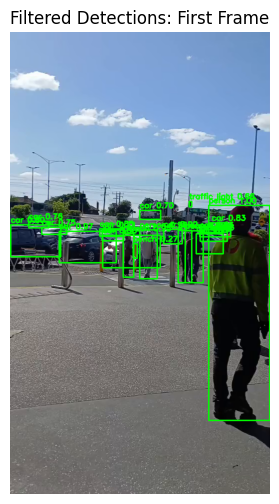

In [19]:
vid.set(cv2.CAP_PROP_POS_FRAMES, 0)
_, img = vid.read()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for b, l, s in zip(filtered_boxes[0], filtered_labels[0], filtered_scores[0]):
    tlx, tly, brx, bry = b.astype(int)
    color = (0, 255, 0)
    cv2.rectangle(img, (tlx, tly), (brx, bry), color, 2)
    cv2.putText(img, f"{l} {s:.2f}", (tlx, tly-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.title("Filtered Detections: First Frame")
plt.axis('off')
plt.show()


## 12. Generate Filtered Detection Video (`task2.mp4`)

An output video is created by overlaying the filtered bounding boxes and labels onto every frame of the source video. This serves as a visual audit of the detection quality before the tracking stage.

The output is written using OpenCV's `VideoWriter` with the `mp4v` codec at the source video's native resolution and frame rate.

In [20]:
vid.set(cv2.CAP_PROP_POS_FRAMES, 0)
fps = vid.get(cv2.CAP_PROP_FPS)
width = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

out_filename = 'task2.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_vid = cv2.VideoWriter(out_filename, fourcc, fps, (width, height))

for i in range(vid_length):
    ret, frame = vid.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    for b, l, s in zip(filtered_boxes[i], filtered_labels[i], filtered_scores[i]):
        tlx, tly, brx, bry = b.astype(int)
        color = (0, 255, 0)
        cv2.rectangle(frame_rgb, (tlx, tly), (brx, bry), color, 2)
        cv2.putText(frame_rgb, f"{l} {s:.2f}", (tlx, tly-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    out_vid.write(frame_bgr)

    if i % 50 == 0:
        print(f"Processed {i}/{vid_length} frames")

out_vid.release()
print(f"Video saved as {out_filename}")


Processed 0/719 frames
Processed 50/719 frames
Processed 100/719 frames
Processed 150/719 frames
Processed 200/719 frames
Processed 250/719 frames
Processed 300/719 frames
Processed 350/719 frames
Processed 400/719 frames
Processed 450/719 frames
Processed 500/719 frames
Processed 550/719 frames
Processed 600/719 frames
Processed 650/719 frames
Processed 700/719 frames
Video saved as task2.mp4


---
# Task 3 - IoU-Based Multi-Class Object Tracking

## 13. IoU-Based Object Tracker

We implement a simple but effective **frame-to-frame IoU tracker**. The key design decisions are:

- **Per-class tracking** — tracks are maintained independently for each object class, ensuring that a single track never spans different semantic categories
- **Greedy IoU matching** — at each frame, active tracks are greedily matched to the nearest detection (by IoU) that exceeds `iou_threshold` (default: `0.3`)
- **Track creation** — unmatched detections spawn new tracks with a unique integer ID
- **Track pruning** — active tracks that fail to match any detection in the current frame are dropped (no re-identification)

**Helper function `iou(boxA, boxB)`** computes the Intersection-over-Union score between two axis-aligned bounding boxes.

In [21]:
def iou(boxA, boxB):
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0

def track_objects(filtered_boxes, filtered_labels, iou_threshold=0.3):
    tracks = {cls: [] for cls in CLASSES_TO_TRACK}
    next_id = {cls: 0 for cls in CLASSES_TO_TRACK}
    active_tracks = {cls: [] for cls in CLASSES_TO_TRACK}

    for frame_idx in range(len(filtered_boxes)):
        frame_tracks = {cls: [] for cls in CLASSES_TO_TRACK}
        for cls in CLASSES_TO_TRACK:
            boxes = [b for b, l in zip(filtered_boxes[frame_idx], filtered_labels[frame_idx]) if l == cls]
            matched = [False]*len(boxes)

            new_active = []
            for tr in active_tracks[cls]:
                best_iou, best_idx = 0, -1
                for idx, box in enumerate(boxes):
                    score = iou(tr['box'], box)
                    if score > best_iou:
                        best_iou, best_idx = score, idx
                if best_iou > iou_threshold:
                    tr['box'] = boxes[best_idx]
                    matched[best_idx] = True
                    frame_tracks[cls].append({'id': tr['id'], 'box': tr['box']})
                    new_active.append(tr)
                else:
                    pass

            for idx, box in enumerate(boxes):
                if not matched[idx]:
                    tr_id = next_id[cls]
                    next_id[cls] += 1
                    new_active.append({'id': tr_id, 'box': box})
                    frame_tracks[cls].append({'id': tr_id, 'box': box})
            active_tracks[cls] = new_active
        for cls in CLASSES_TO_TRACK:
            tracks[cls].append(frame_tracks[cls])
    return tracks

tracks = track_objects(filtered_boxes, filtered_labels)
print("Tracking completed.")


Tracking completed.


## 14. Generate Tracking Visualisation Video (`task3.mp4`)

The final output video overlays per-class colour-coded bounding boxes annotated with:
- The **object class name** and **track ID** (e.g. `person_0`, `chair_2`)
- The **confidence score** (%) from the underlying Mask R-CNN detection

A unique colour is randomly assigned to each class at the start and held constant throughout the video, making it easy to visually distinguish between tracked object categories.

In [22]:
vid.set(cv2.CAP_PROP_POS_FRAMES, 0)
fps = vid.get(cv2.CAP_PROP_FPS)
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter('task3.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
colors = {cls: tuple(np.random.randint(0,255,3).tolist()) for cls in CLASSES_TO_TRACK}

for f_idx in range(len(filtered_boxes)):
    _, frame = vid.read()
    if frame is None:
        break

    for cls in CLASSES_TO_TRACK:
        if len(tracks[cls]) <= f_idx:
            continue
        for tr in tracks[cls][f_idx]:
            b = tr['box'].astype(int)
            color = colors[cls]

            conf = None
            for fb, fl, fs in zip(filtered_boxes[f_idx], filtered_labels[f_idx], filtered_scores[f_idx]):
                if fl == cls and np.allclose(fb, tr['box'], atol=5):
                    conf = fs
                    break

            cv2.rectangle(frame, (b[0], b[1]), (b[2], b[3]), color, 2)
            label = f"{cls}_{tr['id']}"
            if conf is not None:
                label += f" ({conf*100:.1f}%)"

            cv2.putText(frame, label, (b[0], max(b[1]-8, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    out.write(frame)

out.release()
print("Video saved for task3.")


Video saved for task3.
